## Task 4 : Churn Prediction Model

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
df = pd.read_csv(r'C:\Users\akshi\OneDrive\Desktop\Data Analysis\Data Analysis\Saiket Systems\Data\Telco_Customer_Churn_Dataset .csv')

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [7]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in ['customerID', 'Churn']]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

In [8]:
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [10]:
categorical_features = [col for col in X.columns if '_' in col]
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [14]:
X_train = X_train.copy()
X_test = X_test.copy()

In [15]:
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [16]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['gender_Male',
                                                   'SeniorCitizen_Yes',
                                                   'Partner_Yes',
                                                   'Dependent...
                                                   'StreamingTV_No internet '
                                                   'service',
                                                   'StreamingTV_Yes',
                                                   'StreamingMovies_No '
                                                   'internet service',
                                                   'StreamingMovies_Yes',
                                                   'Contract_One year',
                                                   'Contract_Two year',
                                                   'PaperlessBilling_Yes',
                                                   'PaymentMethod_Credit card '
                                                   '(automatic)',
                                                   'PaymentMethod_Electronic '
                                                   'check',
                                                   'PaymentMethod_Mailed '
                                                   'check'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [17]:
y_pred = lr_pipeline.predict(X_test)
y_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance:\n")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

ROC AUC Score: 0.8445


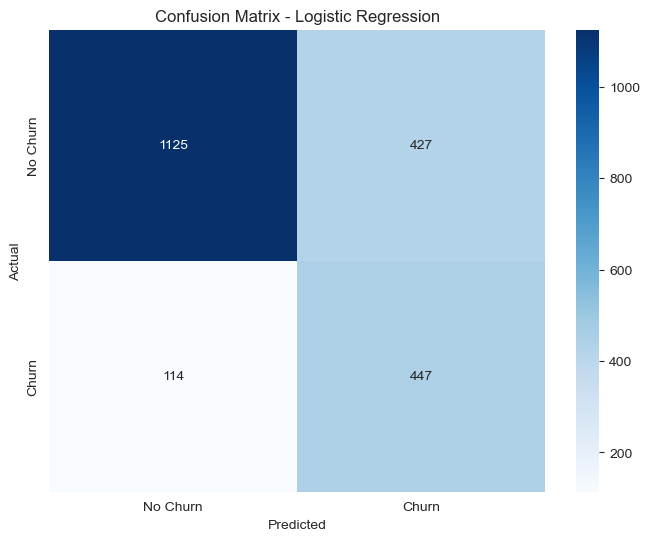

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

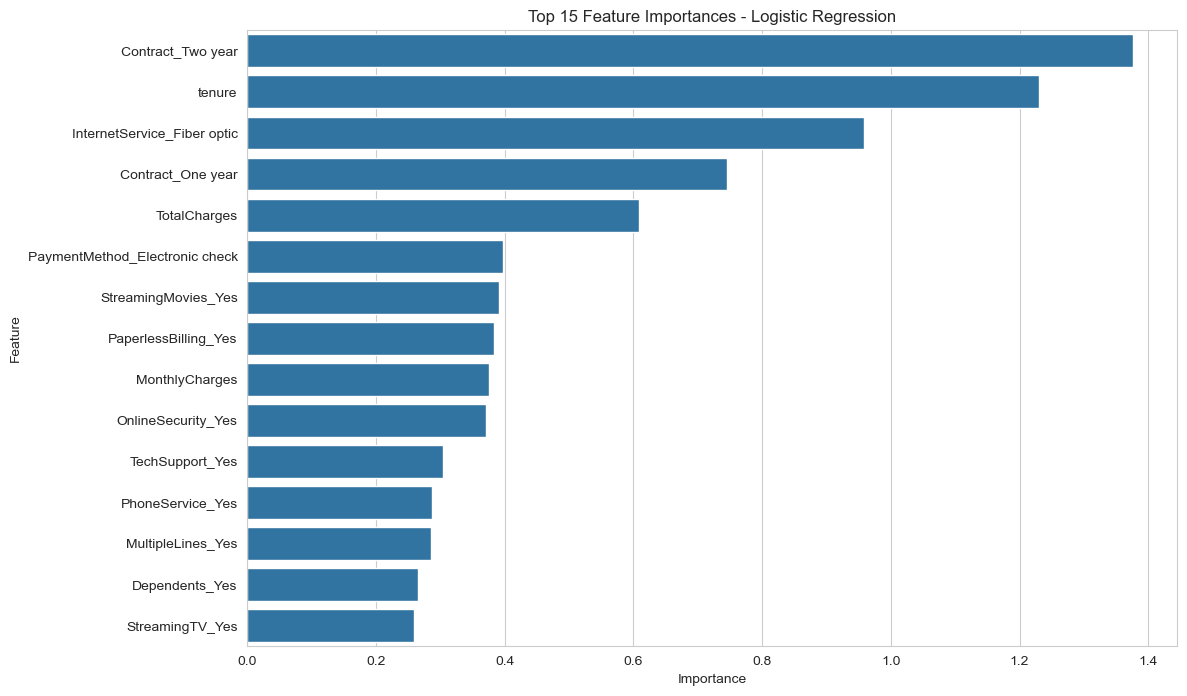

In [19]:
if hasattr(lr_pipeline.named_steps['classifier'], 'coef_'):
    coefficients = lr_pipeline.named_steps['classifier'].coef_[0]
    feature_names = numerical_features + categorical_features
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(coefficients)
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Top 15 Feature Importances - Logistic Regression')
    plt.show()

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance:\n")
print(f"Best Parameters: {grid_search.best_params_}")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

rf_feature_importance = pd.DataFrame({
    'Feature': numerical_features + categorical_features,
    'Importance': best_rf.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance)
plt.title('Top 15 Feature Importances - Random Forest')
plt.show()